# D0 for 1.5T10

In [1]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

In [2]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../MeshPipeline/outputs/ParamOptimisation/optimise_d0') # path to parent of output_root in set_parameters
study_prefix = 'study1' # start of dir name of output_root in set_parameters

out_dir = Path(f'outputs/study1') # path dir to save outputs in
suffixes = ['a', 'b', 'c', 'd'] # individual study identifier (end of dir name of output_root in set_parameters)

In [4]:
get_runtimes(root_dir, study_prefix, suffixes).to_csv(out_dir / 'runtimes.csv', index=False)
extra_params = [
    'cgal_params.optimisation.odt',
    'cgal_params.optimisation.lloyd',
    ]
get_params3d(root_dir, study_prefix, suffixes, extra_params).to_csv(out_dir / 'params.csv', index=False)

prefixes = [f'{study_prefix}{suffix}-0{suffix}' for suffix in suffixes] # only works if only need full_params.json
df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, prefixes)

df_bone.to_csv(out_dir / 'df_bone.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual.csv', index=False)

In [5]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone.csv')
df_cart = pd.read_csv(out_dir / 'df_cart.csv')
df_qual = pd.read_csv(out_dir / 'df_qual.csv')

df_param = pd.read_csv(out_dir / 'params.csv')
df_run = pd.read_csv(out_dir / 'runtimes.csv')

In [6]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'remesh2d'
iteration_bone = 'remesh2d'
loc = 'i'

qual_metric = '99%'
qual_part = 'full'
qual_part2 = 'cart_inner'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    f'{qual_part}_min_angle_{qual_metric}',
    f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_aspect_ratio_{qual_metric}',
    f'{qual_part}_radius_ratio_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',
    f'{qual_part}_aspect_ratio_worst',
    f'{qual_part}_radius_ratio_worst',

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        f'{qual_part2}_min_angle_worst',
        f'{qual_part2}_scaled_jacobian_worst',
        f'{qual_part2}_aspect_ratio_worst',
        f'{qual_part2}_radius_ratio_worst',
        f'{qual_part}_min_angle_{qual_metric}',
        f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_aspect_ratio_{qual_metric}',
        f'{qual_part}_radius_ratio_{qual_metric}',
        'full_n_cells',
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)
df = df[(df['bone_remesh2d_di_max']<0.1)&(df['cart_remesh2d_di_max']<0.1)&(df['full_scaled_jacobian_worst']>0.04)] # remove any where odt chipped tets

#df = df[df['bone']==bone]

print(len(df))

660


Highest element count:
	14874R - 255540


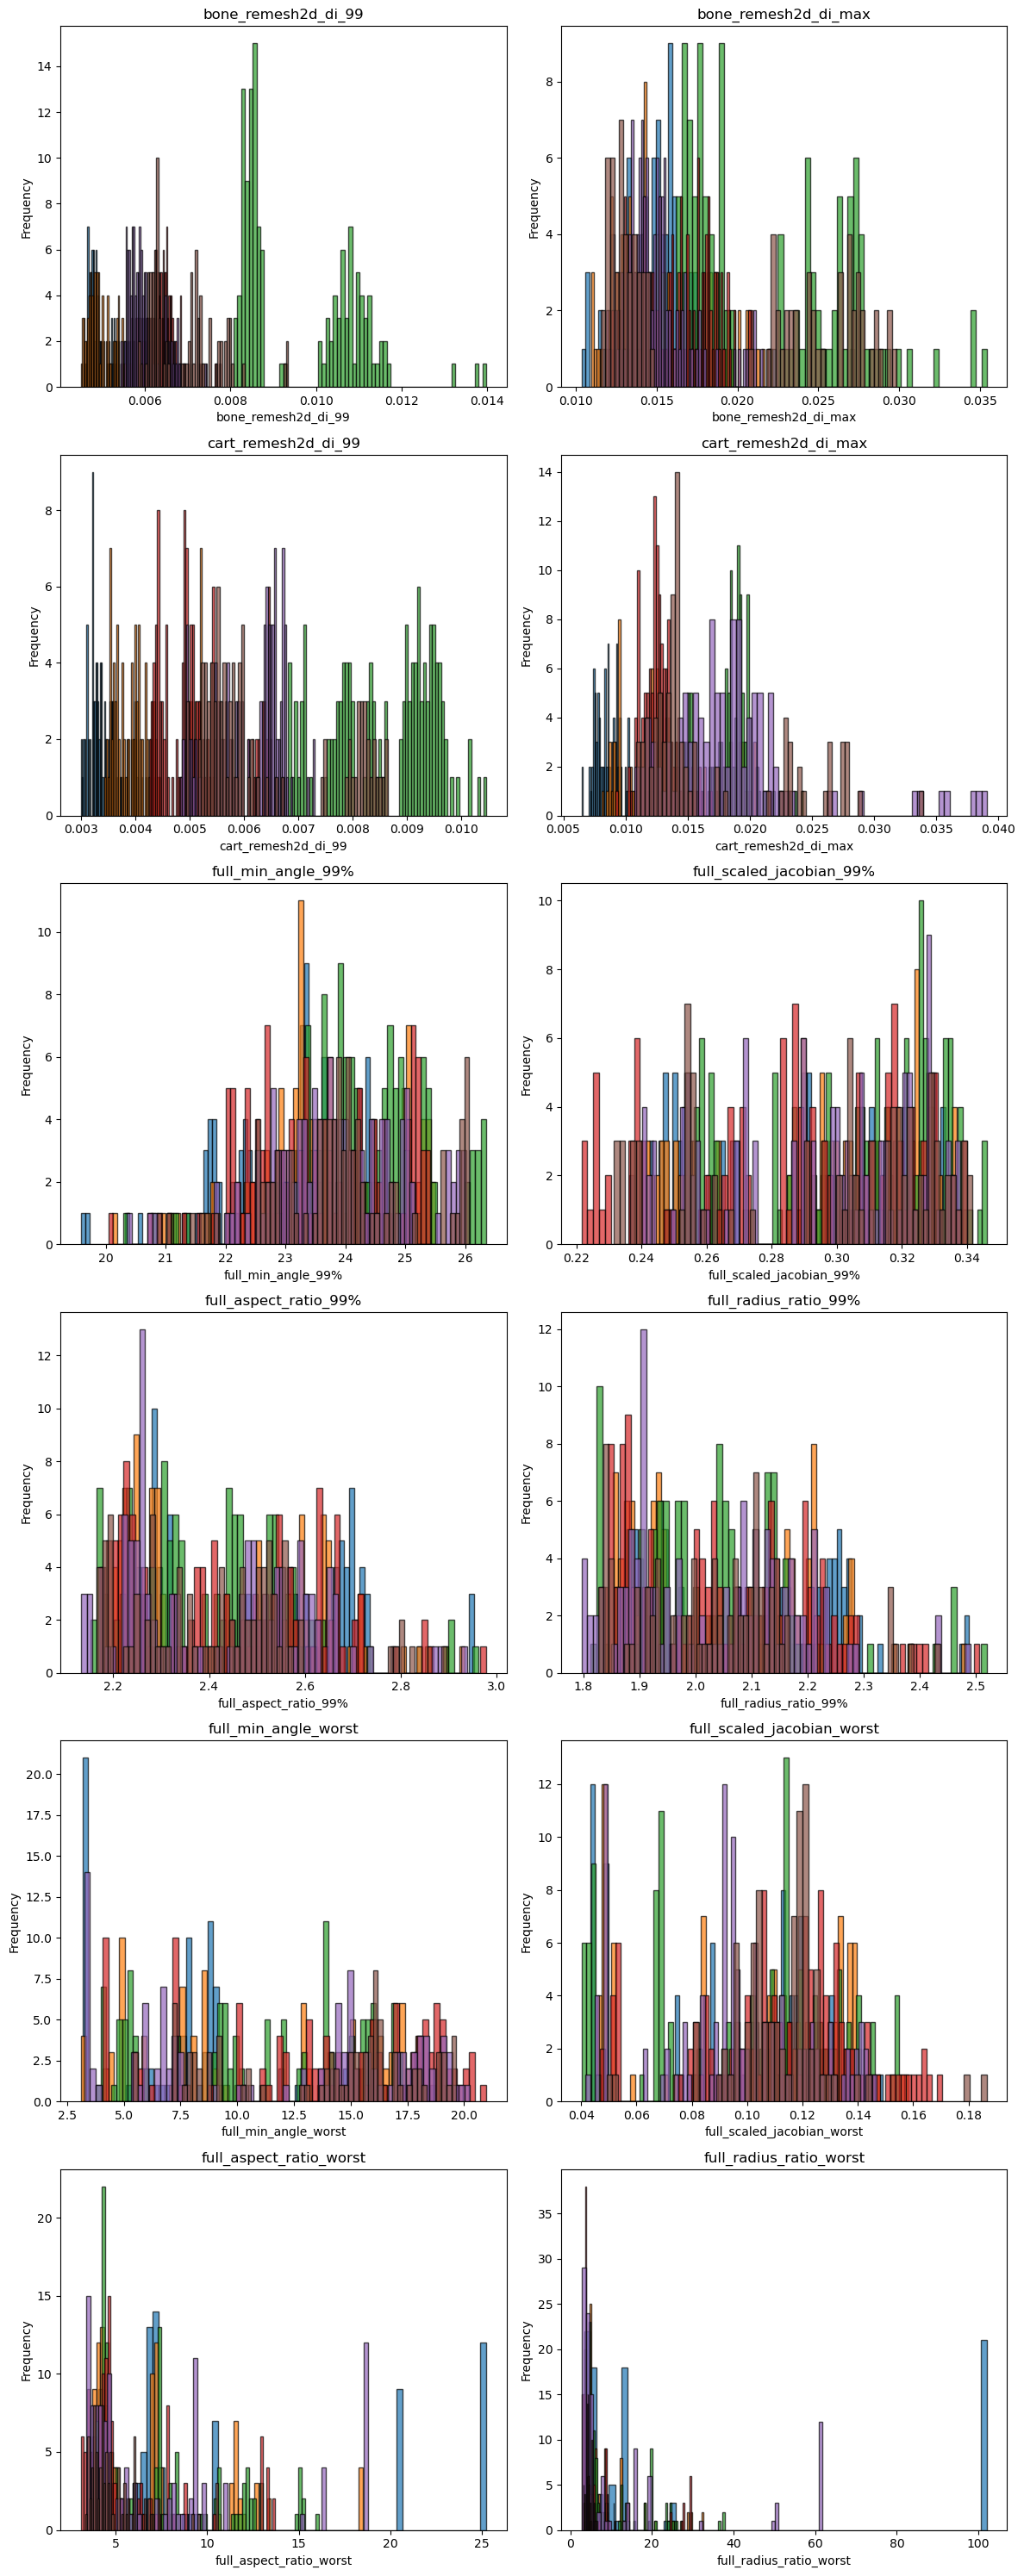

In [8]:
fig, ax = plt.subplots(6, 2, figsize=(12, 30))
ax = ax.flatten()

most_cells = qual.sort_values('full_n_cells').iloc[-1]
print(f'Highest element count:\n\t{most_cells['sub']} - {most_cells['full_n_cells']}')
for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    #print(f"\n{sub}\n - Average edge length: {L:.4f} mm")
    #print(f' -   Max element count: {qual[qual['sub']==sub]['total_tets'].max()}')

    sub_df = df[df['sub']==sub]
    bins = int(len(df) / 10)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        #ax[i].legend()

plt.tight_layout()
plt.show()

In [9]:
q1_weight = 10
q2_weight = 25
q3_weight = 50

chosen_metrics = {

    f'{qual_part2}_min_angle_worst': {
        'ideal': 20,
        'acceptable': 15,
        'weight': q3_weight
    },

    f'{qual_part2}_scaled_jacobian_worst': {
        'ideal': 0.4,
        'acceptable': 0.3,
        'weight': q3_weight
    },

    f'{qual_part2}_aspect_ratio_worst': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q3_weight
    },

    f'{qual_part2}_radius_ratio_worst': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q3_weight
    },




    f'{qual_part}_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q2_weight
    },

    f'{qual_part}_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q2_weight
    },

    f'{qual_part}_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q2_weight
    },

    f'{qual_part}_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q2_weight
    },

    f'{qual_part}_min_angle_99%': {
        'ideal': 30,
        'acceptable': 15,
        'weight': q1_weight
    },

    f'{qual_part}_scaled_jacobian_99%': {
        'ideal': 0.4,
        'acceptable': 0.3,
        'weight': q1_weight
    },

    f'{qual_part}_aspect_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q1_weight
    },

    f'{qual_part}_radius_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q1_weight
    },
}

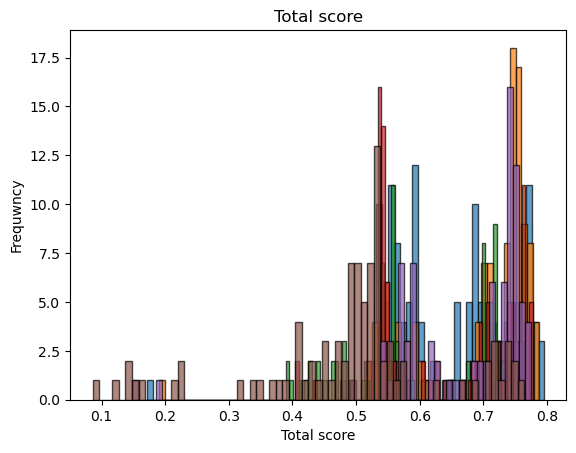

In [11]:
# Get scores

decay = 3
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)

# Merge with params

df_score = df_score.sort_values('total', ascending=False)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)
df_score_qual = df_qual.merge(
    df_score,
    on=['sub', 'bone', 'run_id'],
    how='left'
)

# Plot overall scores
fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/10), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    #ax.legend()

In [12]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank.head(10)

,cgal_params.optimisation.odt,cgal_params.optimisation.lloyd,cgal_params.sizing_field.d0,cgal_params.lloyd.max_iteration_number,cgal_params.lloyd.freeze_bound,cgal_params.odt.max_iteration_number,cgal_params.odt.freeze_bound,mean_rank,median_rank,best_rank,n_runs
33,False,True,6,20.0,0.0010,NaN,NaN,17.333333,5.0,1.0,9
32,False,True,6,20.0,0.0005,NaN,NaN,21.555556,28.0,1.0,9
21,False,True,5,20.0,0.0010,NaN,NaN,22.000000,25.5,1.0,8
20,False,True,5,20.0,0.0005,NaN,NaN,23.000000,18.5,6.0,8
35,False,True,6,30.0,0.0001,NaN,NaN,24.250000,21.5,2.0,8
71,True,False,6,NaN,NaN,30.0,0.0001,24.700000,14.5,5.0,10
64,True,False,6,NaN,NaN,10.0,0.0005,24.850000,23.5,1.5,10
67,True,False,6,NaN,NaN,20.0,0.0001,24.900000,16.0,3.0,10
28,False,True,6,10.0,0.0005,NaN,NaN,25.000000,33.5,2.0,10
27,False,True,6,10.0,0.0001,NaN,NaN,25.000000,28.0,5.0,10


In [14]:
best_per_tet = df_score_param.groupby(['cgal_params.sizing_field.d0', 'sub', 'bone']).first()
best_per_tet

run_id  \
cgal_params.sizing_field.d0 sub    bone              
4                           14874R mc1    0-0-6-0b   
                                   tpm    0-0-2-0a   
                            22306R mc1   0-0-11-0a   
                                   tpm   0-0-12-0a   
                            50000R mc1    0-0-9-0c   
                                   tpm    0-0-7-0d   
                            50017L mc1    0-0-5-0d   
                                   tpm   0-0-12-0d   
                            50034R mc1    0-0-3-0d   
                                   tpm    0-0-4-0c   
                            50037L mc1    0-0-2-0a   
                                   tpm    0-0-9-0a   
5                           14874R mc1   0-0-25-0a   
                                   tpm   0-0-18-0a   
                            22306R mc1   0-0-20-0a   
                                   tpm   0-0-14-0b   
                            50000R mc1   0-0-18-0d   
                                   tpm   0-0-18-0d   
                            50017L mc1   0-0-16-0d   
                                   tpm   0-0-14-0c   
                            50034R mc1   0-0-24-0d   
                                   tpm   0-0-15-0d   
                            50037L mc1   0-0-23-0b   
                                   tpm   0-0-13-0b   
6                           14874R mc1   0-0-34-0a   
                                   tpm   0-0-30-0a   
                            22306R mc1   0-0-32-0a   
                                   tpm   0-0-24-0b   
                            50000R mc1   0-0-26-0d   
                                   tpm   0-0-37-0d   
                            50017L mc1   0-0-33-0d   
                                   tpm   0-0-25-0c   
                            50034R mc1   0-0-33-0d   
                                   tpm   0-0-26-0d   
                            50037L mc1   0-0-31-0a   
                                   tpm   0-0-26-0b   

                                         cart_inner_min_angle_worst  \
cgal_params.sizing_field.d0 sub    bone                               
4                           14874R mc1                     1.000000   
                                   tpm                     1.000000   
                            22306R mc1                     1.000000   
                                   tpm                     1.000000   
                            50000R mc1                     1.000000   
                                   tpm                     1.000000   
                            50017L mc1                     1.000000   
                                   tpm                     1.000000   
                            50034R mc1                     1.000000   
                                   tpm                     1.000000   
                            50037L mc1                     1.000000   
                                   tpm                     1.000000   
5                           14874R mc1                     0.584575   
                                   tpm                     0.908534   
                            22306R mc1                     1.000000   
                                   tpm                     1.000000   
                            50000R mc1                     1.000000   
                                   tpm                     1.000000   
                            50017L mc1                     1.000000   
                                   tpm                     1.000000   
                            50034R mc1                     1.000000   
                                   tpm                     1.000000   
                            50037L mc1                     1.000000   
                                   tpm                     1.000000   
6                           14874R mc1                     1.000000   
                                   tpm                     1.000000   
   

In [27]:
best_per_tet.merge(df_score_qual)[['sub', 'bone', 'run_id', 'full_n_cells']+[x for x in df_score_qual.columns if '_x' in x]]

,sub,bone,run_id,full_n_cells,full_min_angle_worst_x,full_min_angle_99%_x,full_radius_ratio_worst_x,full_radius_ratio_99%_x,full_aspect_ratio_worst_x,full_aspect_ratio_99%_x,full_scaled_jacobian_worst_x,full_scaled_jacobian_99%_x,cart_inner_min_angle_worst_x,cart_inner_radius_ratio_worst_x,cart_inner_aspect_ratio_worst_x,cart_inner_scaled_jacobian_worst_x
0,14874R,mc1,0-0-6-0b,203835,3.191059,23.655747,100.626759,1.941298,20.644154,2.288842,0.048245,0.245497,25.866271,2.037961,2.471368,0.173751
1,14874R,tpm,0-0-2-0a,190128,8.528945,21.768324,7.705682,2.287796,7.514605,2.732119,0.096557,0.290356,21.356055,2.536646,2.922898,0.212499
2,22306R,mc1,0-0-11-0a,81011,15.796656,23.619408,3.926452,2.074260,4.070735,2.488203,0.105798,0.315585,23.975674,2.144902,2.597114,0.247510
3,22306R,tpm,0-0-12-0a,72541,10.059723,20.104090,4.673386,2.483375,5.462299,2.933292,0.124254,0.245349,21.892330,2.784905,3.223148,0.183230
4,50000R,mc1,0-0-9-0c,59231,19.215033,24.459933,2.739140,1.877718,3.101917,2.219780,0.147341,0.265324,26.691054,2.021227,2.442351,0.185086
5,50000R,tpm,0-0-7-0d,49989,18.816053,22.892439,3.886178,2.100459,4.189472,2.520298,0.132482,0.306940,26.200731,1.997058,2.271171,0.231259
6,50017L,mc1,0-0-5-0d,69288,15.003714,23.311253,3.586305,2.132051,4.103073,2.553466,0.130029,0.312346,23.212275,2.087635,2.363569,0.228255
7,50017L,tpm,0-0-12-0d,60028,20.002089,21.992737,3.135186,2.212208,3.711662,2.623187,0.137351,0.253119,22.527938,2.685365,3.110034,0.154059
8,50034R,mc1,0-0-3-0d,80952,16.356333,24.215547,4.159934,2.099674,4.236759,2.502769,0.111382,0.316922,28.125240,1.964370,2.198919,0.212901
9,50034R,tpm,0-0-4-0c,68728,19.156185,23.196273,3.626352,1.936730,3.828664,2.286898,0.120015,0.236841,22.930409,2.461992,2.861856,0.145335


# Thoughts
 - d0 = 5 might work (saves 20000 cells on 14874)
    - would have to check on all meshes though...
 - d0 = 4 has multiple bad meshes
 - d0 = 6 all good